# Modelos de regressão

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
Copyright: Creative Commons

<hr>

## Regressão linear simples

Vamos supor que temos o conjunto de dados abaixo.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
import numpy as np

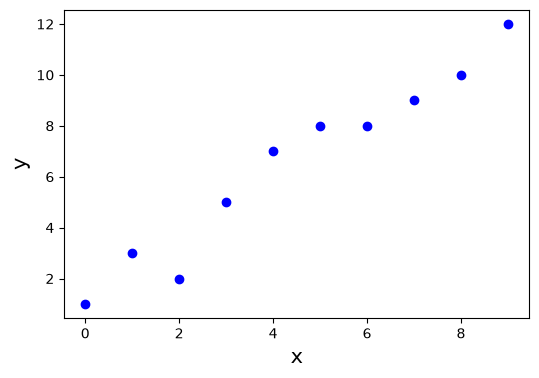

In [15]:
# define os dados
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) 
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12]) 
plt.figure(figsize=(6,4))
plt.plot(x, y, 'bo')
plt.xlabel("x", fontsize = 15)
plt.ylabel("y", fontsize = 15)
plt.show(True)  

Vemos que é uma relação entre as variáveis $X$ e $Y$. Queremos determinar um modelo que melhor descreva essa relação. Podemos supor um modelo de regressão linear simples, como:
$$
y_i \approx \beta_0 + \beta_1x_i
$$

Como há outros fatores, além de $x_i$ que afetam os valores de $y_i$, podemos escrever:
$$
y_i = \beta_0 + \beta_1 x_i + \epsilon_i,
$$
onde $\epsilon_i$ é uma variável aleatória que indica o erro na aproximação. O objetivo dos métodos de regressão é encontrar o melhor valor de $\beta_0$ e $\beta_1$ que minimizem o erro no ajuste. Ou seja, queremos encontrar a linha no plano $xy$ que melhor se ajuste aos dados observados.

Estimando os coeficiente através do método dos momentos ou dos mínimos quadrados, obtemos:
    $$
    \begin{cases}
    \hat{\beta}_1=\frac{\sum_{i=1}^n (x_i- \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = \frac{S{xy}}{S{xx}}\\
    \hat{\beta}_0= \bar{y}-\hat{\beta_1}\bar{x}
    \end{cases}
    $$

Vamos implementar uma função para realizar a estimação.

In [16]:
from statistics import variance 
import math 

def estimate_coef(x, y): 
    # número de observações/pontos
    n = np.size(x) 
  
    # médias de x e y
    mx, my = np.mean(x), np.mean(y) 
  
    # calculating cross-deviation and deviation about x 
    #SS_xy = np.sum(y*x) - n*m_y*m_x 
    #SS_xx = np.sum(x*x) - n*m_x*m_x 
    Sxx = 0
    Sxy = 0
    for i in range(0,len(x)):
        Sxy = Sxy + (x[i]-mx)*(y[i]-my)
        Sxx = Sxx + (x[i]-mx)**2
    
    # calcula os coeficientes de regressão
    b1 = Sxy / Sxx 
    b0 = my - b1*mx 
    return(b0, b1) 

# função para mostrar os dados e o ajuste linear
def plot_regression_line(x, y, b): 
    # mostra os dados
    plt.scatter(x, y, color = "b", marker = "o", s = 50) 
  
    # prediz os valores
    y_pred = b[0] + b[1]*x 
  
    # mostra a reta de regressão
    plt.plot(x, y_pred, color = "r") 
    plt.xlabel('x', fontsize = 15) 
    plt.ylabel('y', fontsize = 15) 
    plt.show(True) 

Assim, aplicando ao conjunto de dados:

Estimated coefficients:
b_0 = 1.2363636363636363  
b_1 = 1.1696969696969697


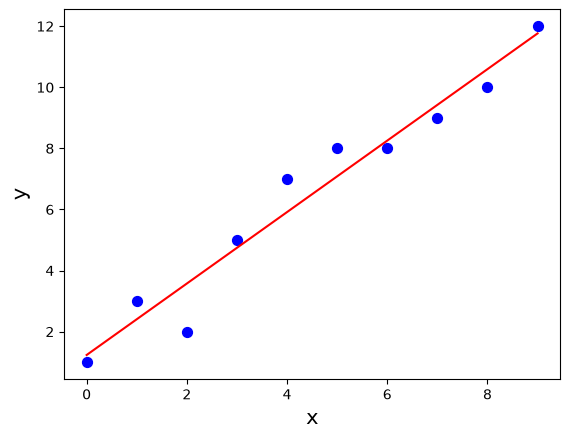

In [19]:
import numpy as np

# estima os coeficientes
b = estimate_coef(x, y) 
print("Estimated coefficients:\nb_0 = {}  \nb_1 = {}".format(b[0], b[1])) 
  
# mostra o ajuste linear
plot_regression_line(x, y, b) 

Para quantificar a acurácia do modelo, usamos o erro padrão residual (residual standard error):
$$
RSE = \sqrt{\frac{1}{n-2}\sum_{i=1}^n (y_i-\hat{y}_i)^2}
$$

In [21]:
# funcao que calcula o RSE
def RSE(x,y,b):
    n = len(y)
    RSE = 0
    for i in range(0,n):
        y_pred = b[0]+ x[i]*b[1] # valor predito
        RSE = RSE + (y[i]-y_pred)**2
    RSE = math.sqrt(RSE/(n-2))
    return RSE
print('RSE:', RSE(x,y,b))

RSE: 0.8384690232980003


Outra medida importante é o coeficiente R2, que mede a proporção da variabilidade em Y que pode ser explicada a partir de X.
$$
R^2 = 1-\frac{\sum_{i=1}^n (y_i-\hat{y}_i)^2}{\sum_{i=1}^n(y_i-\bar{y})^2}, \quad 0\leq R^2\leq 1
$$

In [22]:
def R2(x,y,b):
    n = len(y)
    c1 = 0
    c2 = 0
    ym = np.mean(y)
    for i in range(0,n):
        y_pred = b[0]+ x[i]*b[1] # valor predito
        c1 = c1 + (y[i]-y_pred)**2
        c2 = c2 + (y[i]-ym)**2
    R2 = 1 - c1/c2
    return R2

print('R2:', R2(x,y,b))

R2: 0.952538038613988


Quanto mais próximo de um, melhor é o ajuste da regressão linear.

Notem que o coeficiente $R2$ é igual ao coeficiente de Pearson ao quadrado.

In [23]:
from scipy.stats import pearsonr

print('Pearson ao quadrado:', pearsonr(x,y)[0]**2)

Pearson ao quadrado: 0.9525380386139878


O código completo:

Coeficientes:
b_0 = 1.2363636363636363  
b_1 = 1.1696969696969697
R2: 0.952538038613988


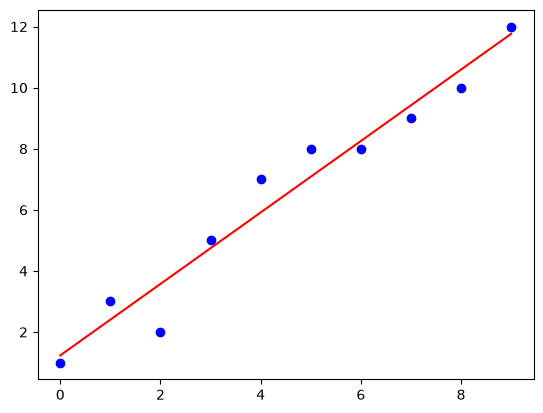

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from statistics import variance 
import math 

# define os dados
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) 
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12]) 

# funcao que estima os coeficientes
def estimate_coef(x, y): 
    # número de observações
    n = np.size(x) 
    # estimadores
    m_x, m_y = np.mean(x), np.mean(y) 
    SS_xy = np.sum(y*x) - n*m_y*m_x 
    SS_xx = np.sum(x*x) - n*m_x*m_x 
    # calcula os coeficientes de regressão
    b_1 = SS_xy / SS_xx 
    b_0 = m_y - b_1*m_x 
    return(b_0, b_1) 

# função para mostrar os dados e o ajuste linear
def plot_regression_line(x, y, b): 
    # mostra os dados
    plt.scatter(x, y, color = "b", marker = "o", s = 50) 
    # prediz os valores
    y_pred = b[0] + b[1]*x 
    # mostra a reta de regressão
    plt.plot(x, y_pred, color = "r") 
    plt.xlabel('x', fontsize = 15) 
    plt.ylabel('y', fontsize = 15) 
    plt.show(True) 
    
def R2(x,y,b):
    n = len(y)
    c1 = 0
    c2 = 0
    ym = np.mean(y)
    for i in range(0,n):
        y_pred = b[0]+ x[i]*b[1] # valor predito
        c1 = c1 + (y[i]-y_pred)**2
        c2 = c2 + (y[i]-ym)**2
    R2 = 1 - c1/c2
    return R2
    
# estima os coeficientes
b = estimate_coef(x, y) 
print("Coeficientes:\nb_0 = {}  \nb_1 = {}".format(b[0], b[1])) 
print('R2:', R2(x,y,b))


# mostra o ajuste linear
plt.plot(x,y,'bo')
plt.plot(x, b[0] + b[1]*x, 'r-')
plt.savefig('plot.eps')

### Inferência sobre o modelo em um conjunto de dados

Vamos realizar uma regressão linear simples entre o investimento em publicidade na televisão (TV) e as vendas (sales). O gráfico apresenta os dados observados e a reta do modelo ajustado.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
np.random.seed(101)

# le os dados
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Advertising.csv', header=(0), index_col=[0])
# Vamos considerar apenas um atributo alvo e uma variável independente
data = data[['TV','sales']]
# valor a ser predito
ylabel = data.columns[-1]
print("Número de linhas e colunas:", data.shape)
data.head(10)
data.head()

Número de linhas e colunas: (200, 2)


,TV,sales
1,230.1,22.1
2,44.5,10.4
3,17.2,9.3
4,151.5,18.5
5,180.8,12.9


In [27]:
# Ajusta o modelo de regressão linear
modelo = ols('sales ~ TV', data=data).fit()

# Exibe o resumo estatístico do modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           1.47e-42
Time:                        16:07:24   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.0

In [28]:
# Obtém os coeficientes estimados
intercepto = modelo.params['Intercept']
coeficiente_tv = modelo.params['TV']

print(f"Intercepto: {intercepto:.4f}")
print(f"Coeficiente de TV: {coeficiente_tv:.4f}")

print(
    f"\nModelo ajustado:\n"
    f"sales = {intercepto:.4f} + {coeficiente_tv:.4f} × TV"
)

Intercepto: 7.0326
Coeficiente de TV: 0.0475

Modelo ajustado:
sales = 7.0326 + 0.0475 × TV


In [29]:
# Calcula os valores preditos para os dados disponíveis
data['sales_predito'] = modelo.predict(data)

display(data.head(10))

,TV,sales,sales_predito
1,230.1,22.1,17.970775
2,44.5,10.4,9.147974
3,17.2,9.3,7.850224
4,151.5,18.5,14.234395
5,180.8,12.9,15.627218
6,8.7,7.2,7.446162
7,57.5,11.8,9.765950
8,120.2,13.2,12.746498
9,8.6,4.8,7.441409
10,199.8,10.6,16.530414


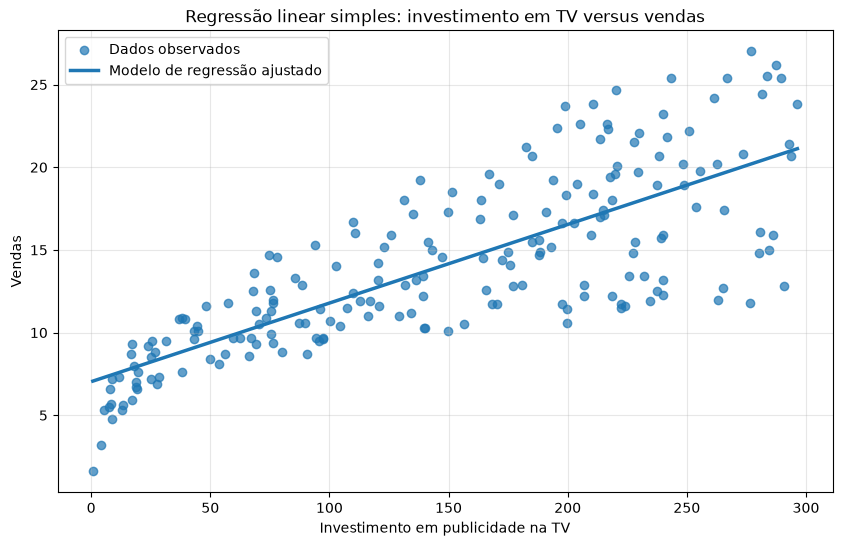

In [30]:
# Ordena os dados segundo a variável TV
# Isso evita que a linha do gráfico fique com segmentos cruzados
data_ordenada = data.sort_values('TV')

plt.figure(figsize=(10, 6))

# Dados observados
plt.scatter(
    data['TV'],
    data['sales'],
    alpha=0.7,
    label='Dados observados'
)

# Reta de regressão
plt.plot(
    data_ordenada['TV'],
    data_ordenada['sales_predito'],
    linewidth=2.5,
    label='Modelo de regressão ajustado'
)

plt.xlabel('Investimento em publicidade na TV')
plt.ylabel('Vendas')
plt.title('Regressão linear simples: investimento em TV versus vendas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [31]:
print(f"R²: {modelo.rsquared:.4f}")
print(f"R² ajustado: {modelo.rsquared_adj:.4f}")
print(f"Erro quadrático médio dos resíduos: {modelo.mse_resid:.4f}")

R²: 0.6119
R² ajustado: 0.6099
Erro quadrático médio dos resíduos: 10.6188


## Exercícios de fixação

1 - Realize uma regressão linear simples entre o investimento em publicidade em rádio (radio). Considere a base Advertising.csv.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
np.random.seed(101)

# le os dados
data = pd.read_csv(r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\Advertising.csv', header=(0), index_col=[0])

# Vamos considerar apenas um atributo alvo e uma variável independente
data = data[['radio','sales']]

# valor a ser predito
ylabel = data.columns[-1]

print("Número de linhas e colunas:", data.shape)
data.head()

Número de linhas e colunas: (200, 2)


,radio,sales
1,37.8,22.1
2,39.3,10.4
3,45.9,9.3
4,41.3,18.5
5,10.8,12.9


In [50]:
# ajusta o modelo
modelo = ols('sales ~ radio', data=data).fit()

# resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     98.42
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           4.35e-19
Time:                        16:16:06   Log-Likelihood:                -573.34
No. Observations:                 200   AIC:                             1151.
Df Residuals:                     198   BIC:                             1157.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.3116      0.563     16.542      0.0

In [53]:
# Obtém os coeficientes estimados
intercepto = modelo.params['Intercept']
coeficiente_radio = modelo.params['radio']

print(f"Intercepto: {intercepto:.4f}")
print(f"Coeficiente de TV: {coeficiente_radio:.4f}")

print(
    f"\nModelo ajustado:\n"
    f"radio = {intercepto:.4f} + {coeficiente_radio:.4f} × TV"
)

Intercepto: 9.3116
Coeficiente de TV: 0.2025

Modelo ajustado:
radio = 9.3116 + 0.2025 × TV


In [56]:
# Calcula os valores preditos para os dados disponíveis
data['sales_predito'] = modelo.predict(data)

display(data.head(10))

,radio,sales,sales_predito
1,37.8,22.1,16.965979
2,39.3,10.4,17.269722
3,45.9,9.3,18.606195
4,41.3,18.5,17.674714
5,10.8,12.9,11.498593
6,48.9,7.2,19.213682
7,32.8,11.8,15.953500
8,19.6,13.2,13.280555
9,2.1,4.8,9.736879
10,2.6,10.6,9.838127


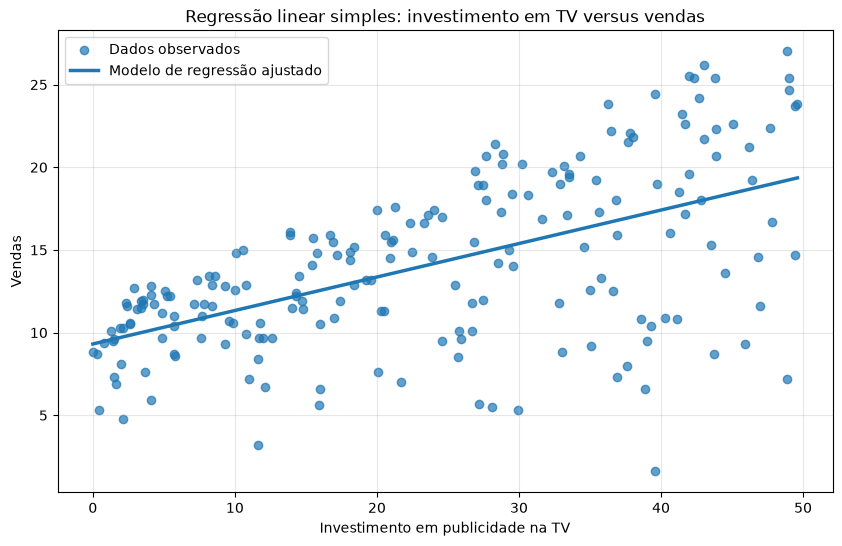

In [57]:
# Ordena os dados segundo a variável TV
# Isso evita que a linha do gráfico fique com segmentos cruzados
data_ordenada = data.sort_values('radio')

plt.figure(figsize=(10, 6))

# Dados observados
plt.scatter(
    data['radio'],
    data['sales'],
    alpha=0.7,
    label='Dados observados'
)

# Reta de regressão
plt.plot(
    data_ordenada['radio'],
    data_ordenada['sales_predito'],
    linewidth=2.5,
    label='Modelo de regressão ajustado'
)

plt.xlabel('Investimento em publicidade na TV')
plt.ylabel('Vendas')
plt.title('Regressão linear simples: investimento em TV versus vendas')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [58]:
print(f"R²: {modelo.rsquared:.4f}")
print(f"R² ajustado: {modelo.rsquared_adj:.4f}")
print(f"Erro quadrático médio dos resíduos: {modelo.mse_resid:.4f}")

R²: 0.3320
R² ajustado: 0.3287
Erro quadrático médio dos resíduos: 18.2751
